# 01 — Samples & Waveforms

**Level:** Beginner

A *sample* is a short buffer of digital audio — numbers that represent air-pressure over time. Sampler-based synthesis starts here: store a clip, then reshape it later with rate, envelope, and filters.

In this notebook you will:
1. Connect sample rate / amplitude to what you hear
2. Generate a few classic waveforms and a plucked “instrument” snippet
3. View **and** play every clip via `hear()`

> Checklist at the end: you should be able to explain what one sample point is, and why 44.1 kHz matters.

## Setup

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

from audio_utils import SR, hear, normalize, seconds, midi_to_hz, apply_adsr

print(f"Project sample rate: {SR} Hz")
print(f"One second of mono audio = {SR:,} floating-point samples")

Project sample rate: 44100 Hz
One second of mono audio = 44,100 floating-point samples


## Digital audio in one picture

Continuous sound pressure is measured **SR** times per second. Each measurement is one *sample* (the noun clashes with “musical sample” — context tells them apart).

Amplitude ≈ −1…+1 in our float buffers. Louder peaks → louder sound (until clipping).

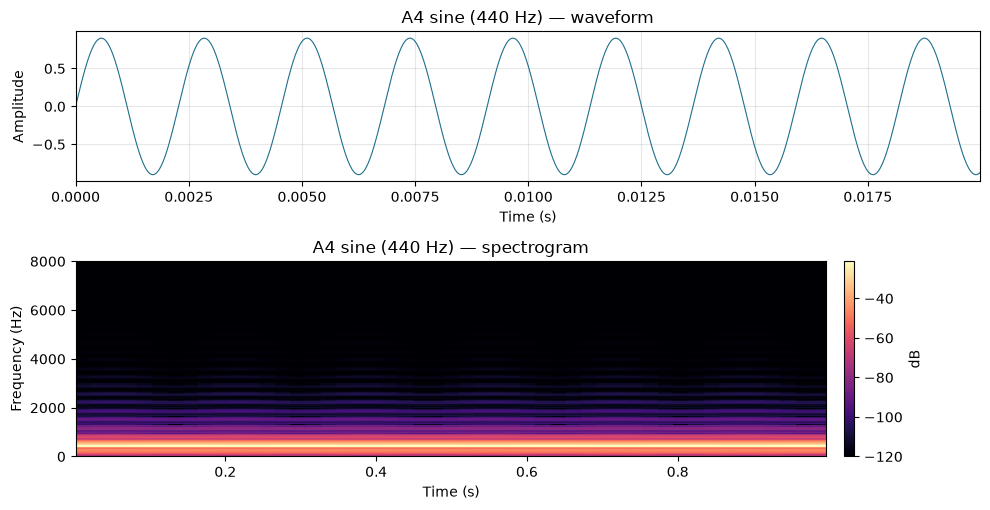

In [2]:
# A pure 440 Hz A4 tone — the simplest possible "sample"
duration = 1.0
t = np.arange(seconds(duration)) / SR
a4 = 0.4 * np.sin(2 * np.pi * 440 * t)

hear(a4, SR, title="A4 sine (440 Hz)", show_spec=True, max_waveform_seconds=0.02)

## Waveform zoo

Same pitch, different spectra → different timbres. Samplers often store complex real-world spectra; these oscillators are the teaching version.

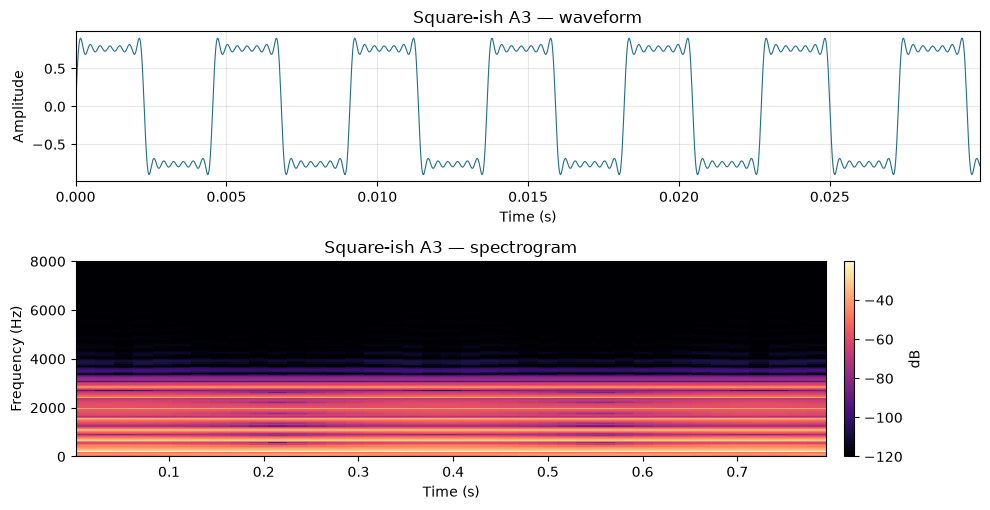

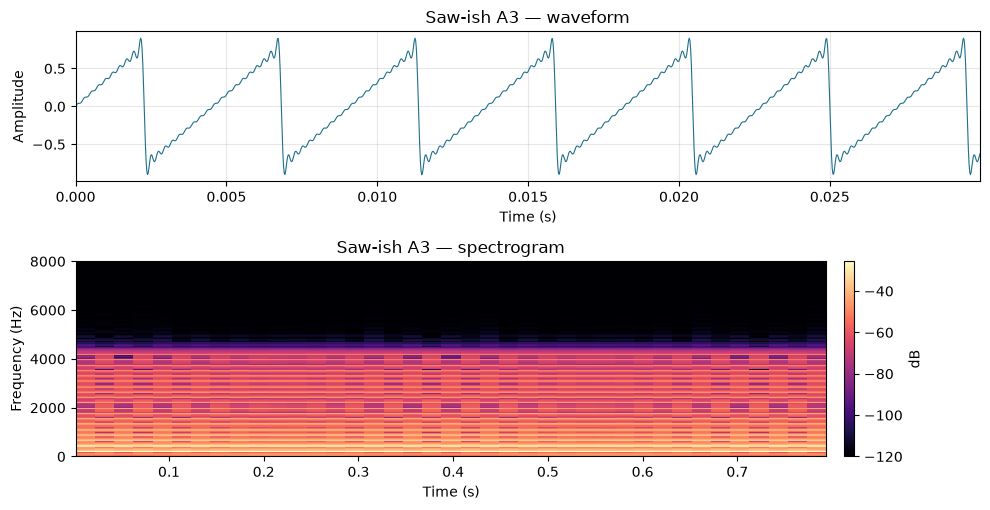

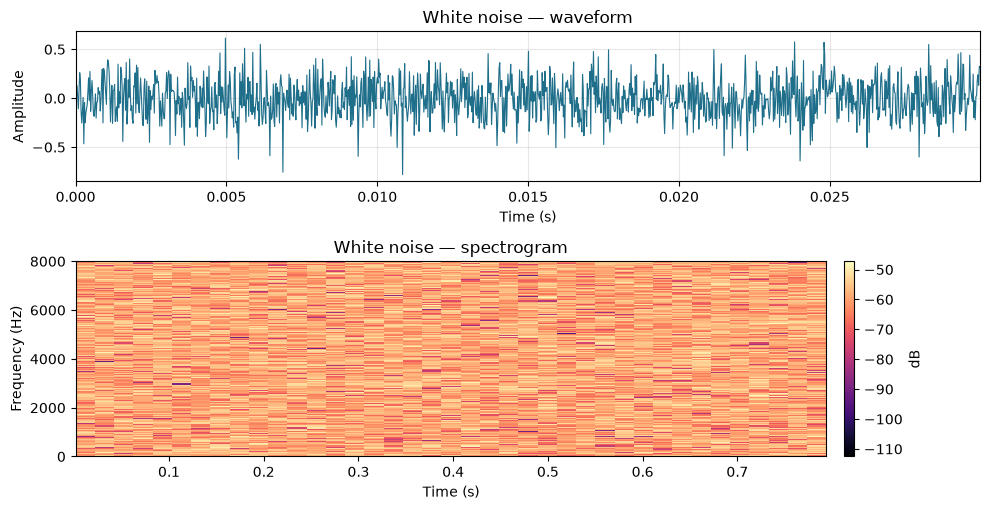

In [3]:
def square(freq, dur, amp=0.35):
    t = np.arange(seconds(dur)) / SR
    # Band-limited-ish via odd harmonics (avoids the harshest aliasing)
    y = np.zeros_like(t)
    for k in range(1, 15, 2):
        y += (1 / k) * np.sin(2 * np.pi * freq * k * t)
    return normalize(y, peak=amp)

def saw(freq, dur, amp=0.35):
    t = np.arange(seconds(dur)) / SR
    y = np.zeros_like(t)
    for k in range(1, 20):
        y += ((-1) ** (k + 1)) / k * np.sin(2 * np.pi * freq * k * t)
    return normalize(y, peak=amp)

def noise(dur, amp=0.25):
    rng = np.random.default_rng(0)
    return normalize(rng.normal(0, 1, seconds(dur)), peak=amp)

freq = 220  # A3
for name, sig in [
    ("Square-ish A3", square(freq, 0.8)),
    ("Saw-ish A3", saw(freq, 0.8)),
    ("White noise", noise(0.8)),
]:
    hear(sig, SR, title=name, show_spec=True, max_waveform_seconds=0.03)

## A musical sample (synthetic plucked string)

Real samplers load WAV/AIFF recordings. Here we synthesize a short decaying “pluck” so the repo stays self-contained — treat it like a recorded one-shot.

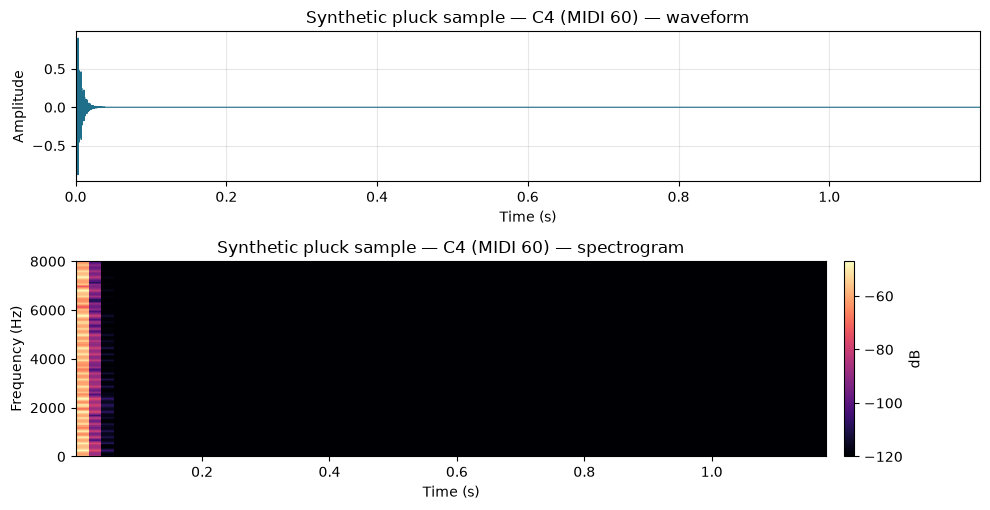

In [4]:
def make_pluck(midi=60, dur=1.2, brightness=0.55):
    """Karplus-Strong-inspired pluck used as a stand-in instrument sample."""
    freq = midi_to_hz(midi)
    n = seconds(dur)
    # Noise burst into a feedback delay line ≈ string length
    delay = max(2, int(round(SR / freq)))
    rng = np.random.default_rng(midi)
    buf = rng.uniform(-1, 1, delay)
    out = np.zeros(n)
    idx = 0
    for i in range(n):
        out[i] = buf[idx]
        avg = brightness * 0.5 * (buf[idx] + buf[(idx + 1) % delay])
        buf[idx] = avg
        idx = (idx + 1) % delay
    return apply_adsr(normalize(out, 0.9), attack=0.002, decay=0.05, sustain=0.55, release=0.35)

pluck_c4 = make_pluck(60)
hear(pluck_c4, SR, title="Synthetic pluck sample — C4 (MIDI 60)", show_spec=True)

## Zoom: what “one cycle” looks like

Early samplers (and wavetable synths) sometimes store only a single cycle and loop it. Compare a long decaying pluck vs. a looping single-cycle tone.

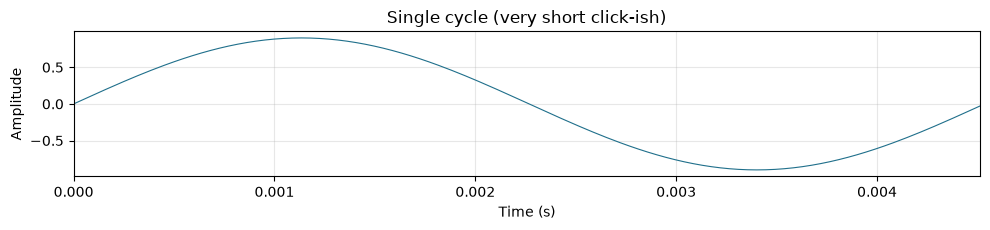

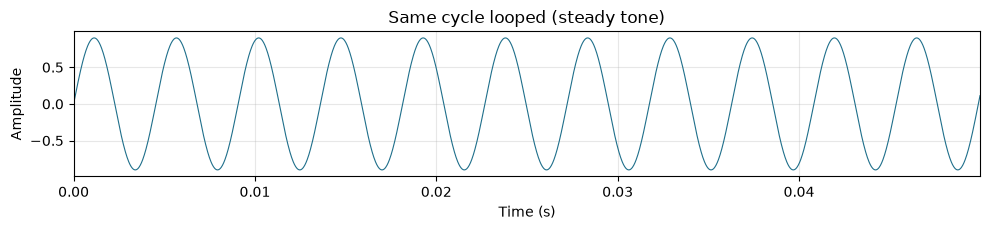

In [5]:
# Extract ~4 periods of a steady sine as a tiny loopable cycle
cycle_freq = 220
samples_per_cycle = int(round(SR / cycle_freq))
cycle = np.sin(2 * np.pi * np.arange(samples_per_cycle) / samples_per_cycle)
looped = np.tile(cycle, 80)  # ~80 cycles ≈ 0.36 s
hear(0.4 * cycle, SR, title="Single cycle (very short click-ish)", max_waveform_seconds=None)
hear(0.4 * looped, SR, title="Same cycle looped (steady tone)", max_waveform_seconds=0.05)

## You should be able to…

- Say what sample rate and amplitude mean in a PCM buffer
- Tell a sine from noise on a spectrogram
- Treat a short buffer as a reusable musical *sample*

**Next:** [02 — Playback rate & pitch](02_playback_rate_and_pitch.ipynb)